# Ischemia in left ventricle model

Running TenTusscherPanfilov2006 on (400, 400) Grid: 100%|██████████| 11999/11999 [00:07<00:00, 1558.64it/s]


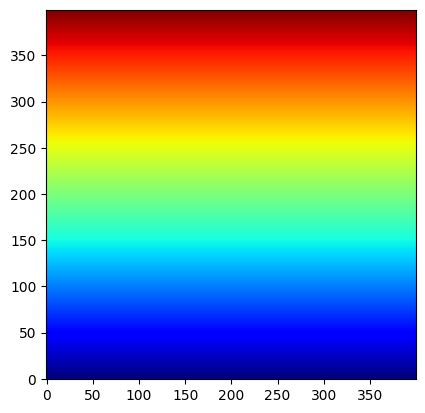

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import finitewave as fw

GRID_SIZE = 400
SPACE_STEP = 0.2

simulation = fw.CardiacSimulation(dt=0.01, t_max=120, backend="mlx")
simulation.cardiac_tissue = fw.CardiacTissue(shape=(GRID_SIZE, GRID_SIZE),
                                             dr=SPACE_STEP)
simulation.cardiac_model = fw.TenTusscherPanfilov2006()
simulation.stim_sequence = fw.StimSequence()
simulation.stim_sequence.add_stim(
    fw.StimCurrentCoord(time=0, curr_value=100, duration=0.5, 
                        x_min=0, x_max=1, y_min=0, y_max=GRID_SIZE)
)
lat_tracker = fw.ActivationTimeTracker(step=10)
simulation.tracker_sequence = fw.TrackerSequence()
simulation.tracker_sequence.add_tracker(lat_tracker)

simulation.run(sync_step=10)

lats = lat_tracker.output

plt.figure()
plt.imshow(lats, cmap="jet", origin="lower")
plt.show()